In [1]:
import pandas as pd  

# Load the dataset (local path, same folder as notebook)
file_path = "co2 Emission Africa.csv"  
df = pd.read_csv(file_path)
# Display the first few rows
df.head()


,Country,Sub-Region,Code,Year,Population,GDP PER CAPITA (USD),GDP PER CAPITA PPP (USD),Area (Km2),Transportation (Mt),Total CO2 Emission including LUCF (Mt),Total CO2 Emission excluding LUCF (Mt),Other Fuel Combustion (Mt),Manufacturing/Construction (Mt),Land-Use Change and Forestry (Mt),Industrial Processes (Mt),Fugitive Emissions (Mt),Energy (Mt),Electricity/Heat (Mt),Bunker Fuels (Mt),Building (Mt)
0,Algeria,Northern Africa,DZA,2000,30774621,1780.38,8510.36,2381741,16.85,80.62,80.05,0.0,6.16,0.57,3.79,14.75,76.26,29.17,1.96,9.33
1,Algeria,Northern Africa,DZA,2001,31200985,1754.58,8840.67,2381741,17.04,76.24,78.65,0.0,6.25,-2.41,3.77,11.86,74.88,30.20,1.98,9.53
2,Algeria,Northern Africa,DZA,2002,31624696,1794.81,9354.22,2381741,19.36,80.00,82.40,0.0,6.62,-2.41,4.06,10.20,78.35,32.28,2.17,9.89
3,Algeria,Northern Africa,DZA,2003,32055883,2117.05,10088.09,2381741,21.76,85.78,88.19,0.0,7.01,-2.41,4.03,12.17,84.16,32.53,1.89,10.68
4,Algeria,Northern Africa,DZA,2004,32510186,2624.80,10653.34,2381741,22.03,87.09,89.49,0.0,8.09,-2.41,4.90,11.22,84.60,31.75,2.19,11.52


In [2]:
# Check basic information
df.info()

# Check for missing values
print("\nMissing Values:\n", df.isnull().sum())

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1134 entries, 0 to 1133
Data columns (total 20 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   Country                                 1134 non-null   object 
 1   Sub-Region                              1134 non-null   object 
 2   Code                                    1134 non-null   object 
 3   Year                                    1134 non-null   int64  
 4   Population                              1134 non-null   int64  
 5   GDP PER CAPITA (USD)                    1107 non-null   float64
 6   GDP PER CAPITA PPP (USD)                1086 non-null   float64
 7   Area (Km2)                              1134 non-null   int64  
 8   Transportation (Mt)                     1122 non-null   float64
 9   Total CO2 Emission including LUCF (Mt)  1134 non-null   float64
 10  Total CO2 Emission excluding LUCF (Mt)  1134 non-null   floa

,Year,Population,GDP PER CAPITA (USD),GDP PER CAPITA PPP (USD),Area (Km2),Transportation (Mt),Total CO2 Emission including LUCF (Mt),Total CO2 Emission excluding LUCF (Mt),Other Fuel Combustion (Mt),Manufacturing/Construction (Mt),Land-Use Change and Forestry (Mt),Industrial Processes (Mt),Fugitive Emissions (Mt),Energy (Mt),Electricity/Heat (Mt),Bunker Fuels (Mt),Building (Mt)
count,1134.000000,1.134000e+03,1107.000000,1086.000000,1.134000e+03,1122.000000,1134.000000,1134.000000,1122.000000,1122.000000,1134.000000,1072.000000,330.000000,1134.000000,1122.000000,1122.000000,1122.000000
mean,2010.000000,1.975236e+07,2220.015953,5106.329926,5.564746e+05,4.913164,41.243289,20.818968,0.434394,2.548387,20.424577,1.114981,4.567152,19.765159,9.272451,0.753788,1.454635
std,6.057972,2.877802e+07,2971.760298,5989.405811,5.983822e+05,10.844025,89.057762,62.186060,1.190362,7.805355,66.859781,2.919895,7.963444,60.348813,38.468534,1.895787,4.303603
min,2000.000000,8.113100e+04,110.460000,420.270000,4.520000e+02,0.010000,-10.410000,0.050000,0.000000,0.000000,-24.950000,0.000000,0.000000,0.050000,0.000000,0.000000,0.000000
25%,2005.000000,2.384106e+06,526.280000,1468.582500,5.678500e+04,0.360000,2.772500,0.810000,0.000000,0.060000,0.105000,0.000000,0.322500,0.782500,0.090000,0.050000,0.040000
50%,2010.000000,1.078683e+07,1009.490000,2544.630000,3.322315e+05,1.065000,14.110000,2.715000,0.030000,0.320000,6.420000,0.080000,1.800000,2.560000,0.305000,0.150000,0.120000
75%,2015.000000,2.359457e+07,2538.470000,6072.067500,9.237680e+05,2.937500,39.772500,7.777500,0.190000,1.460000,17.350000,0.632500,4.762500,7.207500,2.145000,0.640000,0.530000
max,2020.000000,2.083274e+08,19849.720000,33261.870000,2.381741e+06,59.450000,606.390000,448.300000,8.680000,61.100000,601.260000,22.820000,52.490000,443.390000,311.550000,14.790000,33.970000


In [3]:
# Check for missing values
df = df.dropna(thresh=len(df) * 0.5, axis=1)  # Drop columns with more than 50% missing values
df.fillna(df.median(numeric_only=True), inplace=True)  # Fill missing numerical values with median

# Assign cleaned dataset
df_cleaned = df.copy()  # ✅ Now, df_cleaned is defined!

In [4]:
#normalization
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import numpy as np

# Select numerical columns for scaling (excluding categorical)
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Choose either MinMaxScaler or StandardScaler (comment out one)
scaler = MinMaxScaler()  # Normalizes data between 0 and 1
# scaler = StandardScaler()  # Standardizes (mean=0, std=1)

df_scaled = df.copy()  # Create a copy to keep original data
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display normalized data
df_scaled.head()

,Country,Sub-Region,Code,Year,Population,GDP PER CAPITA (USD),GDP PER CAPITA PPP (USD),Area (Km2),Transportation (Mt),Total CO2 Emission including LUCF (Mt),Total CO2 Emission excluding LUCF (Mt),Other Fuel Combustion (Mt),Manufacturing/Construction (Mt),Land-Use Change and Forestry (Mt),Industrial Processes (Mt),Energy (Mt),Electricity/Heat (Mt),Bunker Fuels (Mt),Building (Mt)
0,Algeria,Northern Africa,DZA,0.00,0.147390,0.084599,0.246337,1.0,0.283311,0.147584,0.178472,0.0,0.100818,0.040753,0.166082,0.171900,0.093629,0.132522,0.274654
1,Algeria,Northern Africa,DZA,0.05,0.149438,0.083292,0.256394,1.0,0.286507,0.140483,0.175349,0.0,0.102291,0.035994,0.165206,0.168787,0.096935,0.133874,0.280542
2,Algeria,Northern Africa,DZA,0.10,0.151472,0.085330,0.272032,1.0,0.325538,0.146579,0.183714,0.0,0.108347,0.035994,0.177914,0.176614,0.103611,0.146721,0.291139
3,Algeria,Northern Africa,DZA,0.15,0.153543,0.101655,0.294377,1.0,0.365915,0.155950,0.196631,0.0,0.114730,0.035994,0.176599,0.189719,0.104413,0.127789,0.314395
4,Algeria,Northern Africa,DZA,0.20,0.155725,0.127378,0.311589,1.0,0.370458,0.158074,0.199532,0.0,0.132406,0.035994,0.214724,0.190711,0.101910,0.148073,0.339123


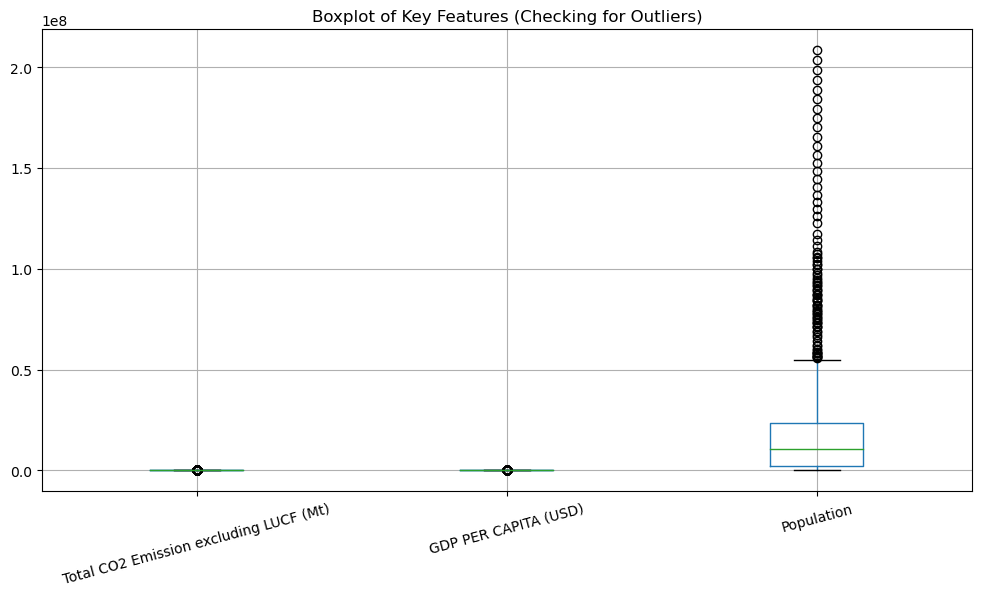

In [5]:
#Check outliers
import matplotlib.pyplot as plt
import seaborn as sns

# Choose key features for outlier detection
features_to_check = ["Total CO2 Emission excluding LUCF (Mt)", "GDP PER CAPITA (USD)", "Population"]

# Plot boxplots
plt.figure(figsize=(12, 6))
df[features_to_check].boxplot()
plt.title("Boxplot of Key Features (Checking for Outliers)")
plt.xticks(rotation=15)
plt.show()

In [6]:

from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Select numerical columns for scaling (excluding categorical)
numerical_cols = df.select_dtypes(include=[np.number]).columns

# Choose either MinMaxScaler or StandardScaler (comment out one)
scaler = MinMaxScaler()  # Normalizes data between 0 and 1
# scaler = StandardScaler()  # Standardizes (mean=0, std=1)

df_scaled = df.copy()  # Create a copy to keep original data
df_scaled[numerical_cols] = scaler.fit_transform(df[numerical_cols])

# Display normalized data
df_scaled.head()


,Country,Sub-Region,Code,Year,Population,GDP PER CAPITA (USD),GDP PER CAPITA PPP (USD),Area (Km2),Transportation (Mt),Total CO2 Emission including LUCF (Mt),Total CO2 Emission excluding LUCF (Mt),Other Fuel Combustion (Mt),Manufacturing/Construction (Mt),Land-Use Change and Forestry (Mt),Industrial Processes (Mt),Energy (Mt),Electricity/Heat (Mt),Bunker Fuels (Mt),Building (Mt)
0,Algeria,Northern Africa,DZA,0.00,0.147390,0.084599,0.246337,1.0,0.283311,0.147584,0.178472,0.0,0.100818,0.040753,0.166082,0.171900,0.093629,0.132522,0.274654
1,Algeria,Northern Africa,DZA,0.05,0.149438,0.083292,0.256394,1.0,0.286507,0.140483,0.175349,0.0,0.102291,0.035994,0.165206,0.168787,0.096935,0.133874,0.280542
2,Algeria,Northern Africa,DZA,0.10,0.151472,0.085330,0.272032,1.0,0.325538,0.146579,0.183714,0.0,0.108347,0.035994,0.177914,0.176614,0.103611,0.146721,0.291139
3,Algeria,Northern Africa,DZA,0.15,0.153543,0.101655,0.294377,1.0,0.365915,0.155950,0.196631,0.0,0.114730,0.035994,0.176599,0.189719,0.104413,0.127789,0.314395
4,Algeria,Northern Africa,DZA,0.20,0.155725,0.127378,0.311589,1.0,0.370458,0.158074,0.199532,0.0,0.132406,0.035994,0.214724,0.190711,0.101910,0.148073,0.339123


In [7]:
# Define a function to remove outliers using the IQR method
def remove_outliers(df, columns):
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1

    # Define lower and upper bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers
    df_filtered = df[~((df[columns] < lower_bound) | (df[columns] > upper_bound)).any(axis=1)]
    return df_filtered

# Apply outlier removal
df_cleaned = remove_outliers(df_scaled, features_to_check)

print(f"Original dataset size: {df.shape[0]}")
print(f"Dataset size after removing outliers: {df_cleaned.shape[0]}")


Original dataset size: 1134
Dataset size after removing outliers: 829


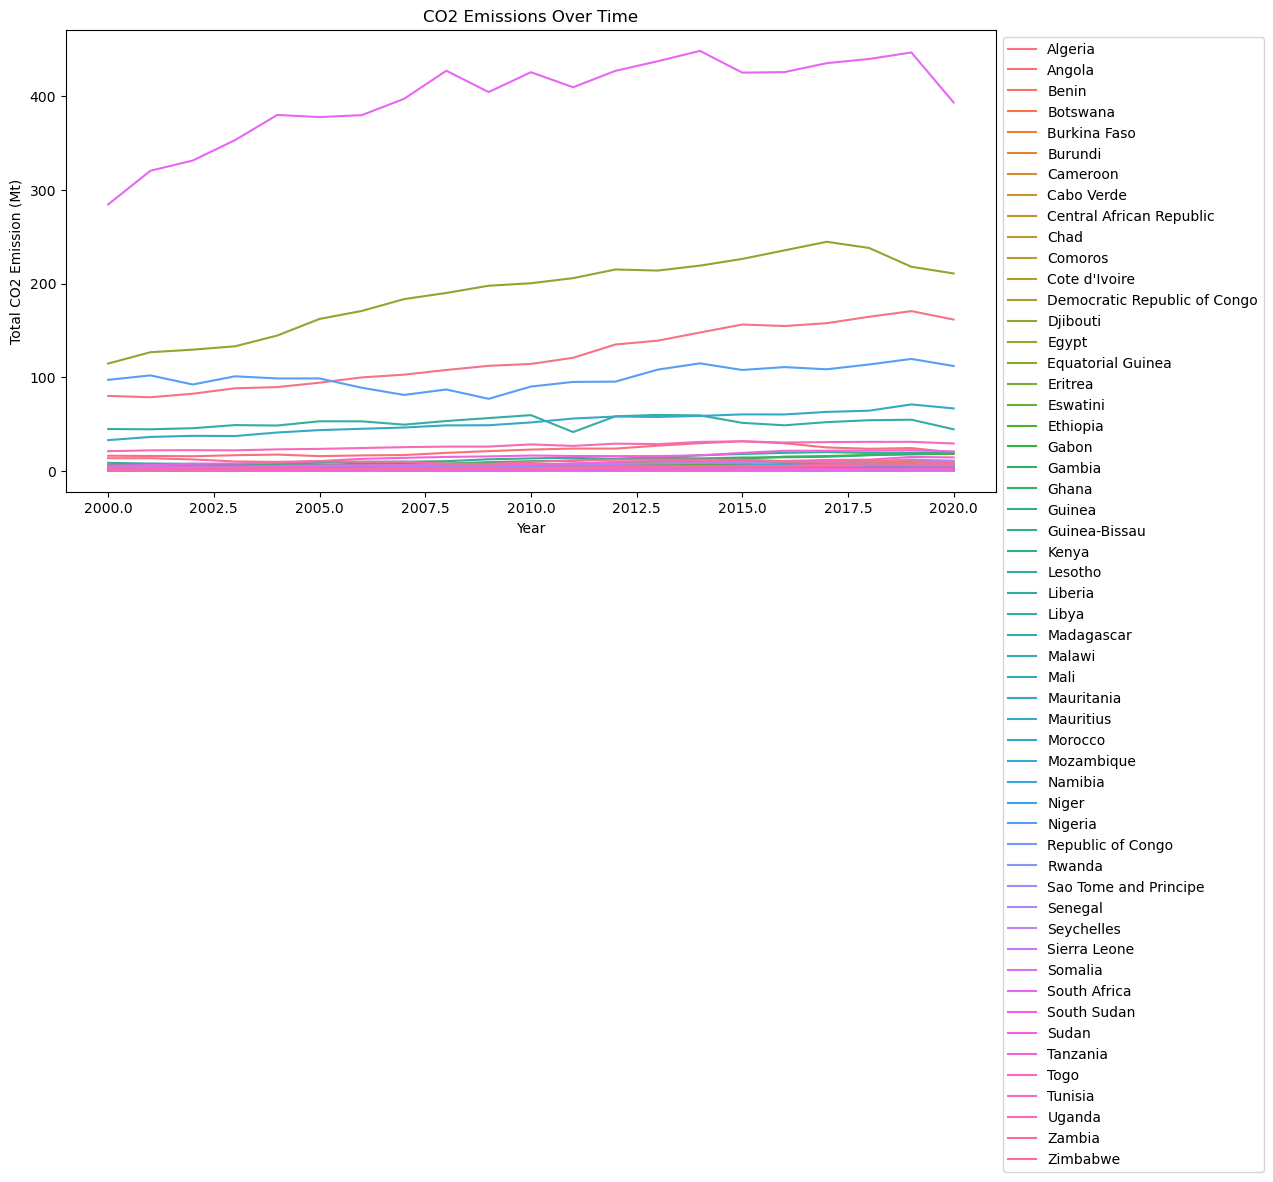

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert 'Year' to numeric if not already
df['Year'] = pd.to_numeric(df['Year'])

# Plot CO2 Emissions trends
plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Year', y='Total CO2 Emission excluding LUCF (Mt)', hue='Country')
plt.title('CO2 Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Total CO2 Emission (Mt)')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.show()

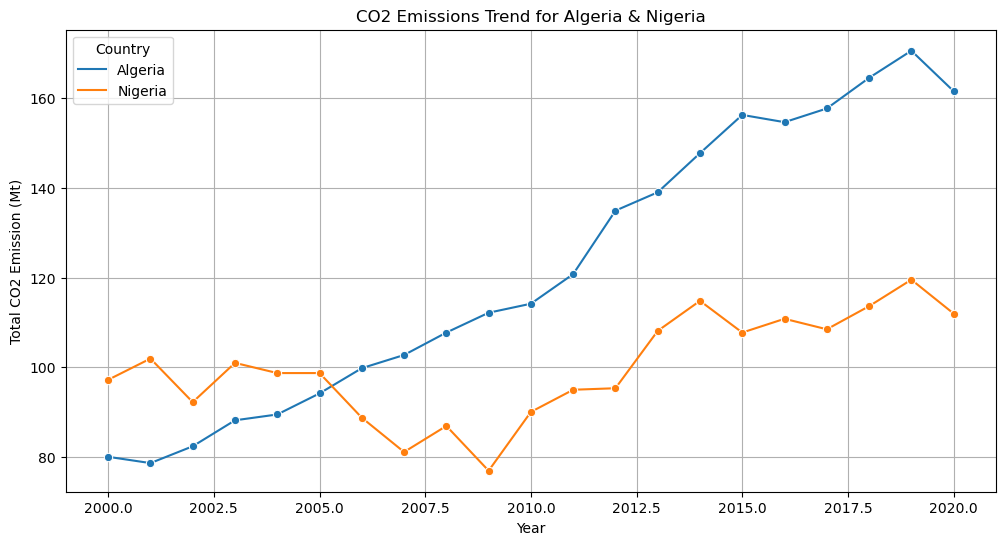

In [9]:
# Choose two countries (change as needed)
countries = ["Algeria", "Nigeria"]

# Filter the dataset for selected countries
df_selected = df[df["Country"].isin(countries)]

# Plot CO₂ Emissions Trends Over Time
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_selected, x="Year", y="Total CO2 Emission excluding LUCF (Mt)", hue="Country", marker="o")

# Customize the plot
plt.title("CO2 Emissions Trend for Algeria & Nigeria")
plt.xlabel("Year")
plt.ylabel("Total CO2 Emission (Mt)")
plt.legend(title="Country")
plt.grid(True)
plt.show()

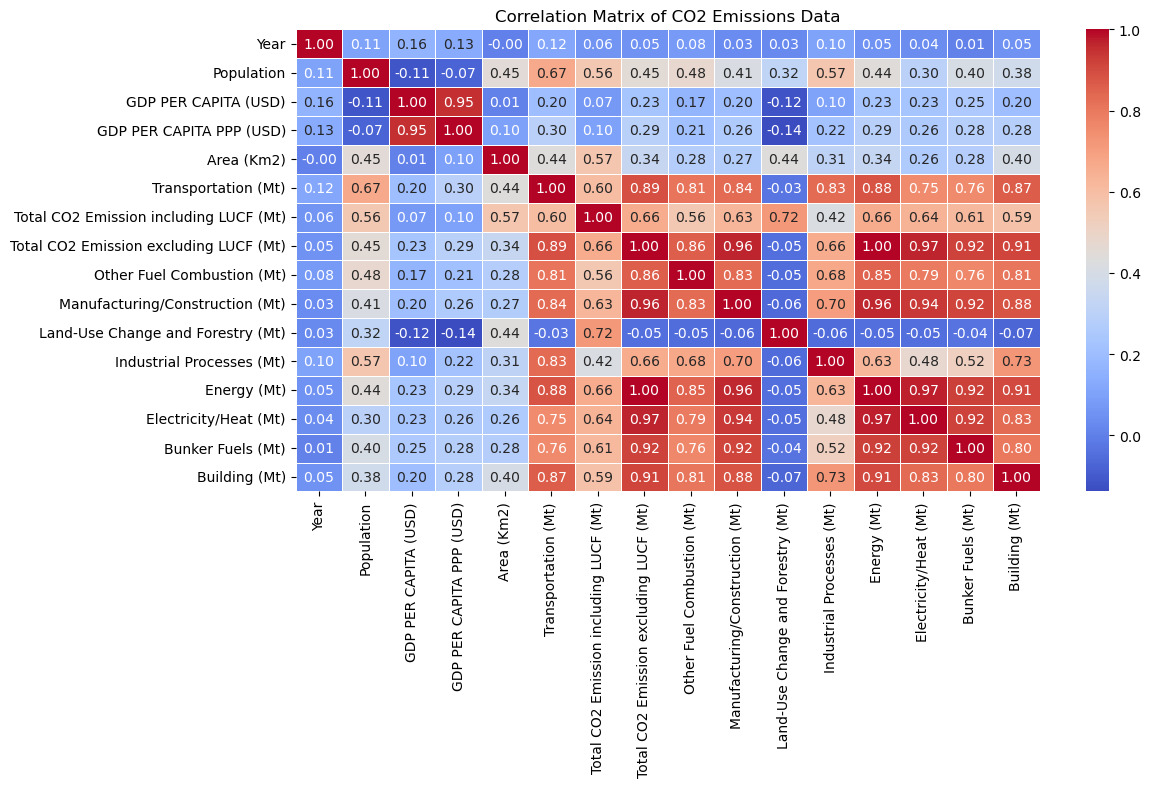

In [10]:
# Compute the correlation matrix
corr_matrix = df.corr(numeric_only=True)

# Plot heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of CO2 Emissions Data')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Select features (independent variables) and target (dependent variable)
features = ["Population", "GDP PER CAPITA (USD)", "Energy (Mt)"]
target = "Total CO2 Emission excluding LUCF (Mt)"

X = df_cleaned[features]
y = df_cleaned[target]

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a regression model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict CO₂ emissions
y_pred = regressor.predict(X_test)

# Evaluate the model
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 0.0004526205711867319
Mean Squared Error (MSE): 8.017115548989525e-07
R² Score: 0.9906685179718979


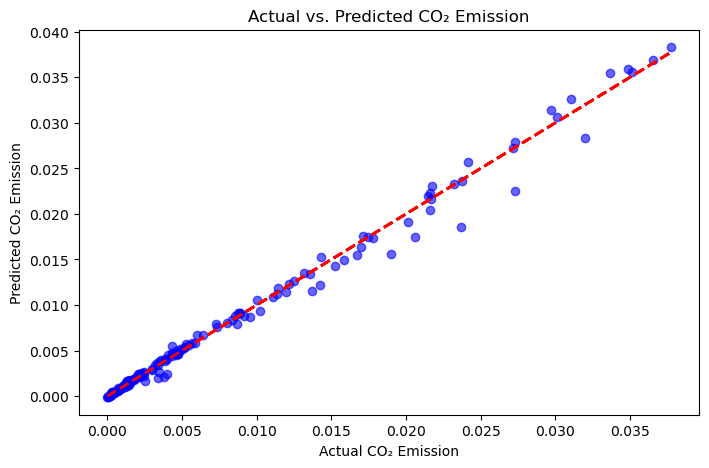

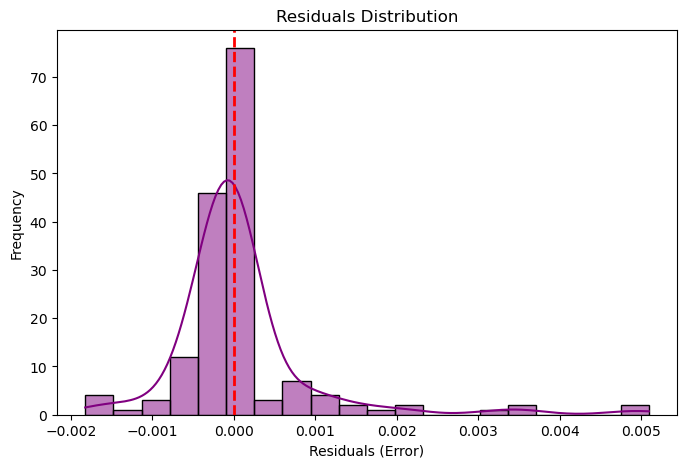

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plot Actual vs Predicted CO₂ Emissions
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, color='blue', alpha=0.6)
plt.plot(y_test, y_test, color='red', linestyle='dashed', linewidth=2)  # Perfect prediction line
plt.xlabel("Actual CO₂ Emission")
plt.ylabel("Predicted CO₂ Emission")
plt.title("Actual vs. Predicted CO₂ Emission")
plt.show()

# Residual Plot (Errors between actual and predicted values)
residuals = y_test - y_pred

plt.figure(figsize=(8,5))
sns.histplot(residuals, bins=20, kde=True, color="purple")
plt.axvline(0, color="red", linestyle="dashed", linewidth=2)
plt.xlabel("Residuals (Error)")
plt.ylabel("Frequency")
plt.title("Residuals Distribution")
plt.show()

In [13]:
import joblib

# Save the trained model
model_filename = "co2_emission_model.pkl"
joblib.dump(regressor, model_filename)

print(f"Model saved as {model_filename}")

Model saved as co2_emission_model.pkl


In [14]:
# Load the saved model
loaded_model = joblib.load(model_filename)

# Make new predictions
new_predictions = loaded_model.predict(X_test)

print("Predictions from loaded model:", new_predictions[:5])  # Show first 5 predictions


Predictions from loaded model: [-0.00011943  0.00230617  0.00091348  0.00476644  0.00012575]


saving cleaned data

In [15]:
df_cleaned.to_csv("cleaned_emissions.csv", index=False)


creating a sqlite database with three tables

In [16]:
import sqlite3

# Connect to (or create) SQLite database
conn = sqlite3.connect("co2_emissions.db")
cursor = conn.cursor()

# Create Country table
cursor.execute("""
CREATE TABLE IF NOT EXISTS Country (
    country_id INTEGER PRIMARY KEY AUTOINCREMENT,
    name TEXT NOT NULL,
    sub_region TEXT,
    code TEXT UNIQUE
);
""")

# Create Year table
cursor.execute("""
CREATE TABLE IF NOT EXISTS Year (
    year_id INTEGER PRIMARY KEY AUTOINCREMENT,
    year INTEGER UNIQUE NOT NULL
);
""")

# Create Emissions table
cursor.execute("""
CREATE TABLE IF NOT EXISTS Emissions (
    emission_id INTEGER PRIMARY KEY AUTOINCREMENT,
    country_id INTEGER,
    year_id INTEGER,
    population INTEGER,
    gdp_per_capita REAL,
    gdp_per_capita_ppp REAL,
    area_km2 INTEGER,
    transportation_mt REAL,
    total_emission_incl_lucf REAL,
    total_emission_excl_lucf REAL,
    other_fuel_combustion_mt REAL,
    manufacturing_construction_mt REAL,
    land_use_change_forestry_mt REAL,
    industrial_processes_mt REAL,
    fugitive_emissions_mt REAL,
    energy_mt REAL,
    electricity_heat_mt REAL,
    bunker_fuels_mt REAL,
    building_mt REAL,
    FOREIGN KEY (country_id) REFERENCES Country(country_id),
    FOREIGN KEY (year_id) REFERENCES Year(year_id)
);
""")

# Commit changes and close connection
conn.commit()
conn.close()

print("✅ Tables created successfully in SQLite database.")


✅ Tables created successfully in SQLite database.


Insert unique countries into the country table

In [17]:
import sqlite3

# Re-load cleaned data
import pandas as pd
df = pd.read_csv("co2 Emission Africa.csv")

# Connect to SQLite DB
conn = sqlite3.connect("co2_emissions.db")
cursor = conn.cursor()

# Get unique countries and their metadata
country_data = df[['Country', 'Sub-Region', 'Code']].drop_duplicates()

# Insert each unique country
for _, row in country_data.iterrows():
    cursor.execute("""
    INSERT OR IGNORE INTO Country (name, sub_region, code)
    VALUES (?, ?, ?)
    """, (row['Country'], row['Sub-Region'], row['Code']))

conn.commit()
print(f"✅ Inserted {len(country_data)} countries into the Country table.")


✅ Inserted 54 countries into the Country table.


Insert unique years into the year table

In [18]:
# Get unique years
unique_years = df['Year'].drop_duplicates().sort_values()

# Insert each unique year
for year in unique_years:
    cursor.execute("""
    INSERT OR IGNORE INTO Year (year)
    VALUES (?)
    """, (int(year),))

conn.commit()
print(f"✅ Inserted {len(unique_years)} years into the Year table.")


✅ Inserted 21 years into the Year table.


Insert Emissions data

In [19]:
# Function to get country_id and year_id
def get_ids(country, year):
    cursor.execute("SELECT country_id FROM Country WHERE name = ?", (country,))
    country_id = cursor.fetchone()
    cursor.execute("SELECT year_id FROM Year WHERE year = ?", (year,))
    year_id = cursor.fetchone()
    return (country_id[0] if country_id else None, year_id[0] if year_id else None)

# Iterate over each row in the DataFrame
for _, row in df.iterrows():
    country_id, year_id = get_ids(row['Country'], row['Year'])
    
    cursor.execute("""
    INSERT INTO Emissions (
        country_id, year_id, population, gdp_per_capita, gdp_per_capita_ppp,
        area_km2, transportation_mt, total_emission_incl_lucf, total_emission_excl_lucf,
        other_fuel_combustion_mt, manufacturing_construction_mt, land_use_change_forestry_mt,
        industrial_processes_mt, fugitive_emissions_mt, energy_mt, electricity_heat_mt,
        bunker_fuels_mt, building_mt
    ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
    """, (
        country_id, year_id,
        row['Population'], row['GDP PER CAPITA (USD)'], row['GDP PER CAPITA PPP (USD)'],
        row['Area (Km2)'], row['Transportation (Mt)'], row['Total CO2 Emission including LUCF (Mt)'],
        row['Total CO2 Emission excluding LUCF (Mt)'], row['Other Fuel Combustion (Mt)'],
        row['Manufacturing/Construction (Mt)'], row['Land-Use Change and Forestry (Mt)'],
        row['Industrial Processes (Mt)'], row['Fugitive Emissions (Mt)'], row['Energy (Mt)'],
        row['Electricity/Heat (Mt)'], row['Bunker Fuels (Mt)'], row['Building (Mt)']
    ))

conn.commit()
conn.close()
print("✅ Emissions data successfully inserted into the Emissions table.")


✅ Emissions data successfully inserted into the Emissions table.


Top 5 Highest Total C02 emitting countries (excludng LUCF) overall

In [20]:
query = """
SELECT c.name AS country, ROUND(SUM(e.total_emission_excl_lucf), 2) AS total_emissions
FROM Emissions e
JOIN Country c ON e.country_id = c.country_id
GROUP BY c.name
ORDER BY total_emissions DESC
LIMIT 5;
"""

top_emitters = pd.read_sql_query(query, sqlite3.connect("co2_emissions.db"))
top_emitters


,country,total_emissions
0,South Africa,192467.22
1,Egypt,91521.37
2,Algeria,58819.97
3,Nigeria,48280.45
4,Morocco,24952.47


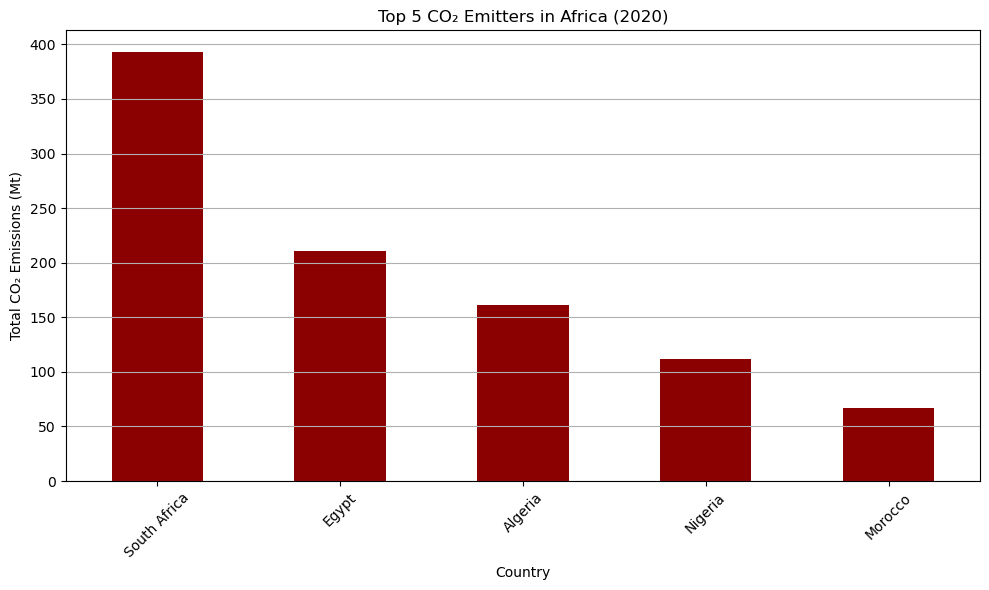

In [21]:
import matplotlib.pyplot as plt

# Filter to the latest year in your dataset
latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year]

# Group by country and sum emissions, then get top 5
top_emitters = (
    df_latest.groupby('Country')['Total CO2 Emission excluding LUCF (Mt)']
    .sum()
    .nlargest(5)
)

# Plot the Top 5 Emitters
plt.figure(figsize=(10, 6))
top_emitters.plot(kind='bar', color='darkred')

plt.title(f'Top 5 CO₂ Emitters in Africa ({latest_year})')
plt.xlabel('Country')
plt.ylabel('Total CO₂ Emissions (Mt)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y')

plt.show()


How emissions changed over time in Nigeria,Kenya, South Africa

In [22]:
query = """
SELECT c.name AS country, y.year, e.total_emission_excl_lucf
FROM Emissions e
JOIN Country c ON e.country_id = c.country_id
JOIN Year y ON e.year_id = y.year_id
WHERE c.name IN ('Nigeria', 'Kenya', 'South Africa')
ORDER BY c.name, y.year;
"""

trend_df = pd.read_sql_query(query, sqlite3.connect("co2_emissions.db"))


Visualization Using matplotlib

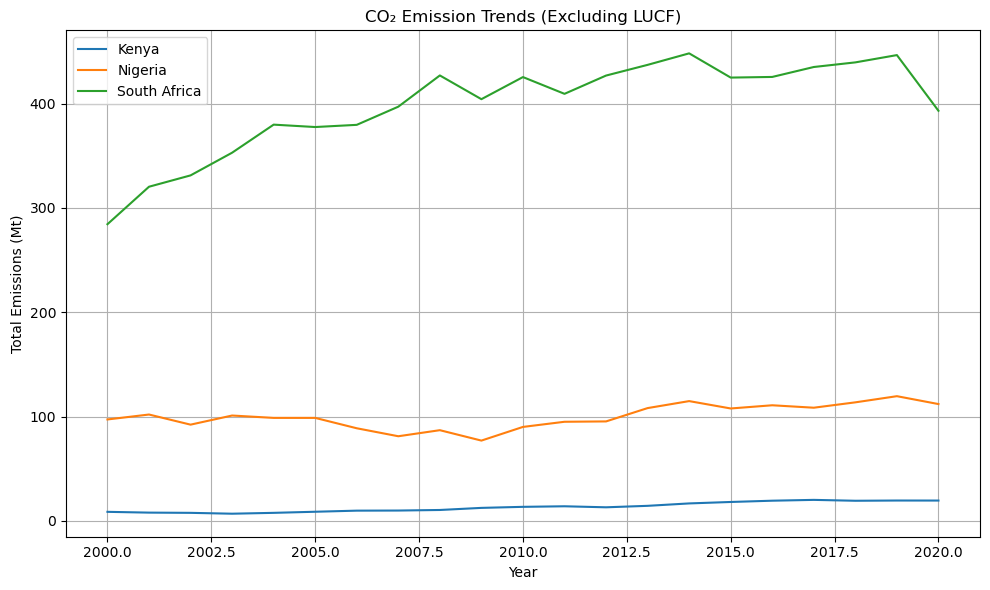

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for country in trend_df['country'].unique():
    country_data = trend_df[trend_df['country'] == country]
    plt.plot(country_data['year'], country_data['total_emission_excl_lucf'], label=country)

plt.title('CO₂ Emission Trends (Excluding LUCF)')
plt.xlabel('Year')
plt.ylabel('Total Emissions (Mt)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Year with the highest total emissions across Africa

In [24]:
query = """
SELECT y.year, ROUND(SUM(e.total_emission_excl_lucf), 2) AS total_emissions
FROM Emissions e
JOIN Year y ON e.year_id = y.year_id
GROUP BY y.year
ORDER BY total_emissions DESC
LIMIT 1;
"""

pd.read_sql_query(query, sqlite3.connect("co2_emissions.db"))


,year,total_emissions
0,2019,31726.43


Emissions per capita-Top 10 records

In [25]:
import sqlite3
import pandas as pd

# Ensure the connection is open
conn = sqlite3.connect("co2_emissions.db")

query = """
SELECT c.name AS country, y.year,
       ROUND(e.total_emission_excl_lucf / e.population, 5) AS emissions_per_capita
FROM Emissions e
JOIN Country c ON e.country_id = c.country_id
JOIN Year y ON e.year_id = y.year_id
WHERE e.population > 0
ORDER BY emissions_per_capita DESC
LIMIT 10;
"""

emissions_per_capita = pd.read_sql_query(query, conn)
print(emissions_per_capita)

# Optional: Close after you're done
conn.close()


             country  year  emissions_per_capita
0  Equatorial Guinea  2004               0.00001
1  Equatorial Guinea  2005               0.00001
2  Equatorial Guinea  2006               0.00001
3  Equatorial Guinea  2007               0.00001
4  Equatorial Guinea  2008               0.00001
5  Equatorial Guinea  2009               0.00001
6  Equatorial Guinea  2010               0.00001
7  Equatorial Guinea  2011               0.00001
8              Libya  2000               0.00001
9              Libya  2001               0.00001


Relationship between GDP per capita and CO2 Emissions

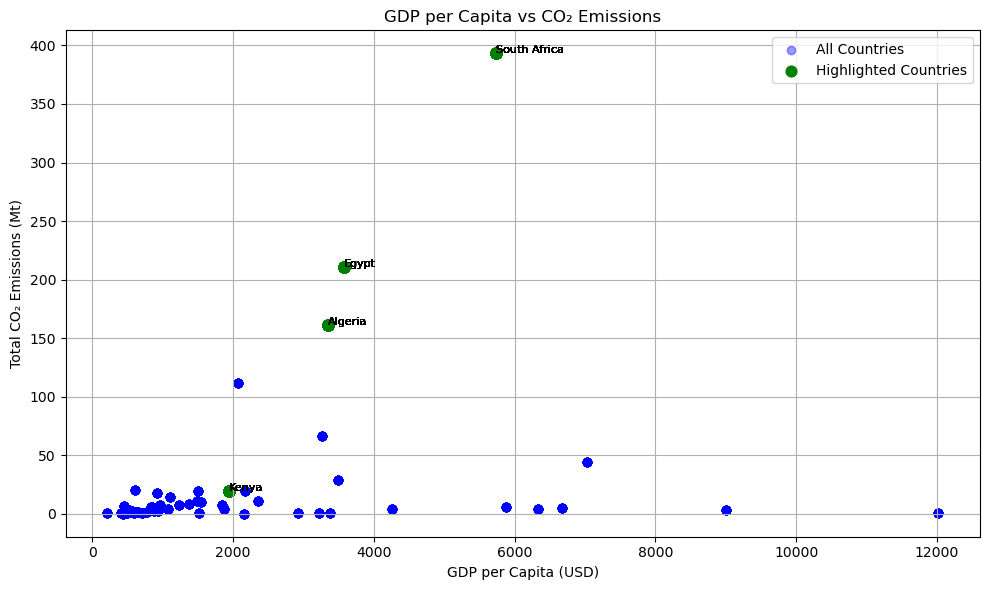

In [31]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# ✅ Step 1: Re-open the connection
conn = sqlite3.connect("co2_emissions.db")

# ✅ Step 2: Modified query to include country names
query = """
SELECT c.name AS country, e.gdp_per_capita, e.total_emission_excl_lucf
FROM Emissions e
JOIN Country c ON e.country_id = c.country_id
WHERE e.gdp_per_capita IS NOT NULL AND e.total_emission_excl_lucf IS NOT NULL
AND e.year_id = (SELECT MAX(year_id) FROM Emissions)
"""

gdp_emissions = pd.read_sql_query(query, conn)
conn.close()

# ✅ Step 3: Select countries to highlight
highlight = gdp_emissions[gdp_emissions['country'].isin(['South Africa', 'Egypt', 'Kenya', 'Algeria'])]

# ✅ Step 4: Create the scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(gdp_emissions['gdp_per_capita'], gdp_emissions['total_emission_excl_lucf'], alpha=0.4, color='blue', label='All Countries')
plt.scatter(highlight['gdp_per_capita'], highlight['total_emission_excl_lucf'], color='green', s=60, label='Highlighted Countries')

# ✅ Step 5: Add labels
for _, row in highlight.iterrows():
    plt.text(
        row['gdp_per_capita'],
        row['total_emission_excl_lucf'],
        row['country'],
        fontsize=8,
        alpha=0.9
    )

plt.title('GDP per Capita vs CO₂ Emissions')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Total CO₂ Emissions (Mt)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


Total CO2 Emissions Over Time

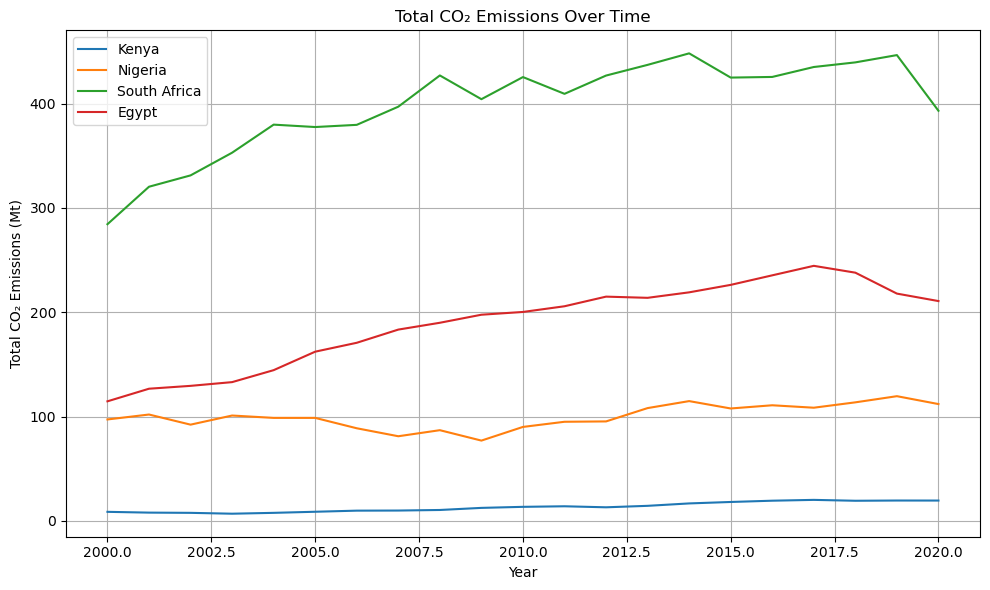

In [32]:
import matplotlib.pyplot as plt

# Ensure 'Year' is numeric
df['Year'] = df['Year'].astype(int)

# Select countries to plot
selected_countries = ['Kenya', 'Nigeria', 'South Africa', 'Egypt']

# Plot emissions over time
plt.figure(figsize=(10, 6))
for country in selected_countries:
    subset = df[df['Country'] == country]
    plt.plot(subset['Year'], subset['Total CO2 Emission excluding LUCF (Mt)'], label=country)

plt.title('Total CO₂ Emissions Over Time')
plt.xlabel('Year')
plt.ylabel('Total CO₂ Emissions (Mt)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


CO2 Emissions Per capita over time

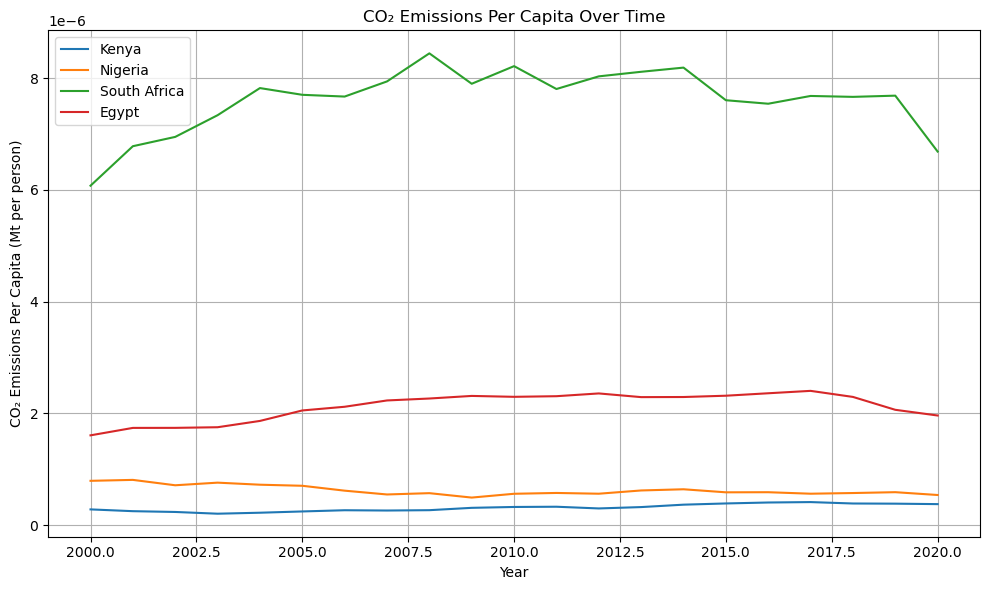

In [33]:
# Calculate emissions per capita
df['CO2_per_Capita'] = df['Total CO2 Emission excluding LUCF (Mt)'] / df['Population']

# Plot per capita emissions
plt.figure(figsize=(10, 6))
for country in selected_countries:
    subset = df[df['Country'] == country]
    plt.plot(subset['Year'], subset['CO2_per_Capita'], label=country)

plt.title('CO₂ Emissions Per Capita Over Time')
plt.xlabel('Year')
plt.ylabel('CO₂ Emissions Per Capita (Mt per person)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


GDP VS TOTAL CO2 EMISSIONS(LATEST YEAR)

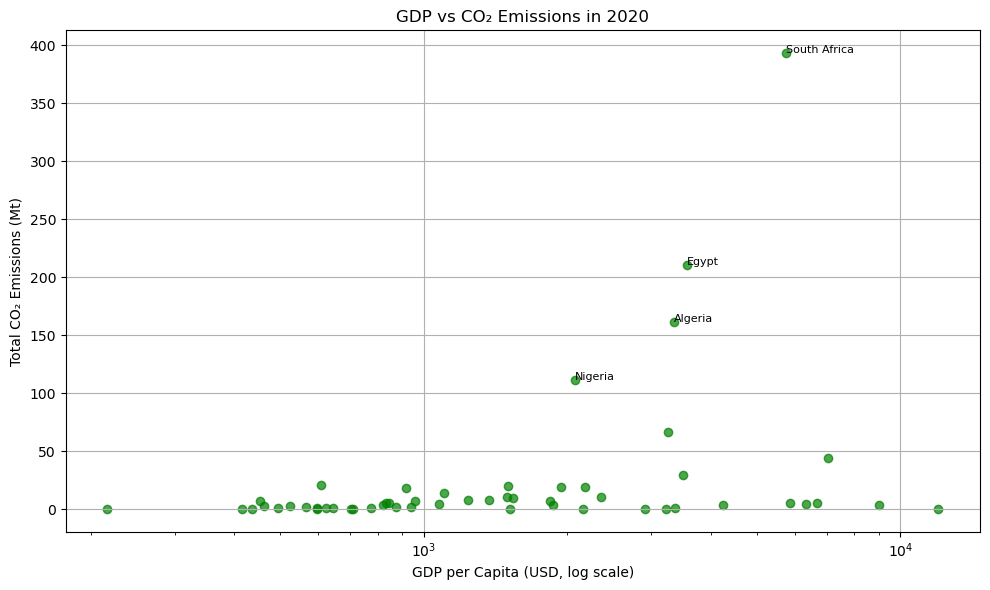

In [34]:
# Latest year available
latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year]

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df_latest['GDP PER CAPITA (USD)'], df_latest['Total CO2 Emission excluding LUCF (Mt)'], color='green', alpha=0.7)

# Optional: log scale for GDP
plt.xscale('log')

# Label countries with high emissions
for i, row in df_latest.iterrows():
    if row['Total CO2 Emission excluding LUCF (Mt)'] > 100:
        plt.text(row['GDP PER CAPITA (USD)'], row['Total CO2 Emission excluding LUCF (Mt)'], row['Country'], fontsize=8)

plt.title(f'GDP vs CO₂ Emissions in {latest_year}')
plt.xlabel('GDP per Capita (USD, log scale)')
plt.ylabel('Total CO₂ Emissions (Mt)')
plt.grid(True)
plt.tight_layout()
plt.show()


Average Emissions by Sub-Region

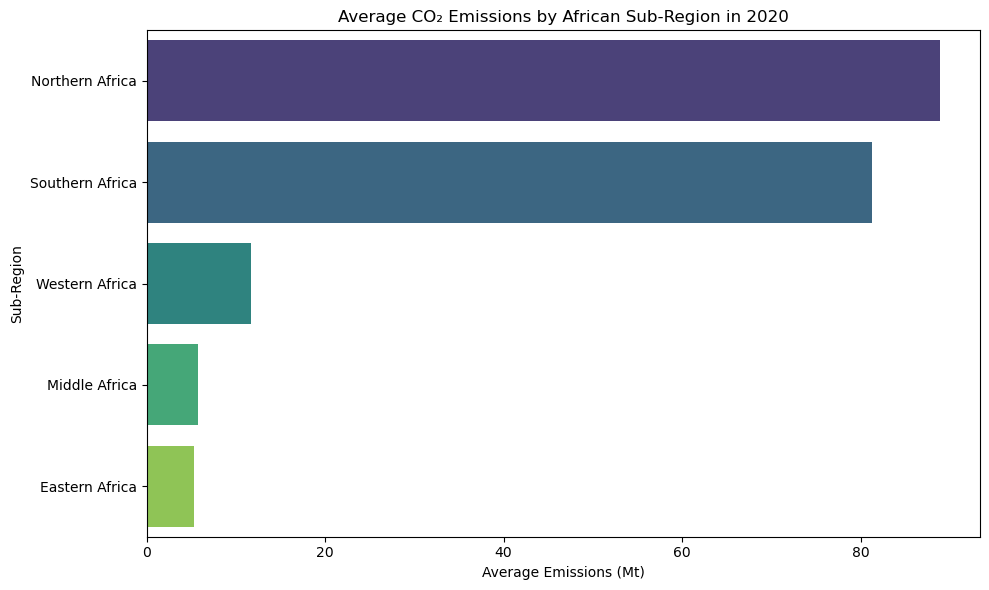

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter to latest year
latest_year = df['Year'].max()
df_latest = df[df['Year'] == latest_year]

# Group by Sub-Region and calculate average emissions
region_avg = df_latest.groupby('Sub-Region')['Total CO2 Emission excluding LUCF (Mt)'].mean().sort_values(ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=region_avg.values, y=region_avg.index, palette='viridis')

plt.title(f'Average CO₂ Emissions by African Sub-Region in {latest_year}')
plt.xlabel('Average Emissions (Mt)')
plt.ylabel('Sub-Region')
plt.tight_layout()
plt.show()
